In [2]:
%load_ext IPython.extensions.autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')


In [3]:
import sys
sys.path.append('../')
from model import FinData
from model import train_valid_test_split
from model import CatboostFinModel, SVMFinModel
from model import precision_long, recall_long, fbeta_metric_long

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import pandas as pd
import numpy as np

import json
import datetime as dt
import pandas as pd
import optuna

In [7]:
company_name = 'Gazprom'
df_path = '../datasets/' + company_name + '_1_min.csv'

start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 4, 1)
cutoff_time = start_time - dt.timedelta(days=90)

findata = FinData(df_path)
findata.restrict_time_down(cutoff_time)
findata.restrict_time_up(end_time + dt.timedelta(days=2))
findata.insert_all()

cat_feats = findata.cat_features
num_feats = findata.numeric_features
target = 'direction_binary_0'

data = findata.df

In [9]:
data = pd.read_csv("MMK_long_valid.csv")
y_pred = (data.predicted_proba > 0.5).astype(int)
close = data.close
y_true = (data.close.shift(-1) > data.close).astype(int)

print(fbeta_metric_long(y_pred, close, commission=0.0008, beta=1))
fbeta_metric_long(y_pred, close, commission=0.0008, beta=0.005)


0.038140747176368374


0.6092657074556854

In [10]:
from sklearn.metrics import precision_score
precision_score(y_true=y_true, y_pred=y_pred)

0.7527777777777778

In [11]:
precision_long(y_pred, close, commission=0.0008)


0.6097222222222223

In [12]:
recall_long(y_pred, close, commission=0.0008)

0.01968609865470852

In [15]:
args1 = {
    "iterations": 10000,
    "depth": 5,
    "learning_rate": 0.02,
    "use_best_model": True,
    "l2_leaf_reg": 200,
    "loss_function": 'Logloss',
    "eval_metric": 'Logloss',
    "random_state": 42,
    "verbose": 0,
    "early_stopping_rounds": 500
}



def objective(trial):
    weight_1 = trial.suggest_float("unimp_weight", 0.01, 0.2)
    # proportion = trial.suggest_float("proportion", 1, 3)

    curr_time = start_time

    f1_scores = []

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        # print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
        #             Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
        #             Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]
        close = test_df['close']

        sample_weights_train = pd.Series(1.0, index=train_df.index) # x 
        sample_weights_val = pd.Series(1.0, index=val_df.index)  # x
        
        mask_train = train_df['close'].shift(-1) > train_df['close'] 
        mask_val = val_df['close'].shift(-1) > val_df['close'] 

        sample_weights_train.loc[mask_train] = weight_1
        sample_weights_val.loc[mask_val] = weight_1  

        # mask_train = train_df['close'].shift(-1)/train_df['close'] > 1.0008
        # mask_val = val_df['close'].shift(-1)/val_df['close'] > 1.0008 

        # sample_weights_train.loc[mask_train] = weight_1 * proportion
        # sample_weights_val.loc[mask_val] = weight_1 * proportion 

        model = CatboostFinModel(args1)
        model.set_datasets(X_train, X_val, y_train, y_val)
        model.set_features(num_feats, cat_feats)
        model.fit(sample_weights_train=sample_weights_train, sample_weights_val=sample_weights_val)
        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]
        preds = (proba > 0.5).astype(int)
        f1_scores.append(fbeta_metric_long(preds, close, commission=0.0008, beta=0.005))

        curr_time = curr_time + dt.timedelta(days=5)

    return np.mean(f1_scores)
    

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=7)

print("Лучшие параметры:")
print(study.best_params)
print("Лучшее значение F-beta:")
print(study.best_value)
    


    

[I 2025-07-22 01:26:25,652] A new study created in memory with name: no-name-b448aa60-115e-4a71-93b7-529dca316840
[I 2025-07-22 01:36:40,272] Trial 0 finished with value: 0.5573347761931428 and parameters: {'unimp_weight': 0.17784833785004606}. Best is trial 0 with value: 0.5573347761931428.
[W 2025-07-22 01:39:35,906] Trial 1 failed with parameters: {'unimp_weight': 0.1420813935971632} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "c:\Users\Валерия\OneDrive\Документы\GitHub\prices-predictions\myenv\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Валерия\AppData\Local\Temp\ipykernel_6604\911595952.py", line 57, in objective
    model.fit(sample_weights_train=sample_weights_train, sample_weights_val=sample_weights_val)
  File "c:\Users\Валерия\OneDrive\Документы\GitHub\prices-predictions\research\..\model\model.py", line 125, in fi

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import datetime as dt

args1 = {
    "iterations": 10000,
    "depth": 5,
    "learning_rate": 0.02,
    "use_best_model": True,
    "l2_leaf_reg": 200,
    "loss_function": 'Logloss',
    "eval_metric": 'Logloss',
    "random_state": 42,
    "verbose": 0,
    "early_stopping_rounds": 500
}

companies_names = ['Gazprom']
dfs = ["../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2024, 3, 1)
start_time = dt.datetime(2024, 5, 1)
end_time = dt.datetime(2024, 12, 31)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        sample_weights_train = pd.Series(1.0, index=train_df.index)
        sample_weights_val = pd.Series(1.0, index=val_df.index)  # новый код
        
        mask_train = train_df['close'].shift(-1) > train_df['close']
        mask_val = val_df['close'].shift(-1) > val_df['close']  # новый код

        sample_weights_train.loc[mask_train] = 0.25
        sample_weights_val.loc[mask_val] = 0.25  # новый код

        mask_train = train_df['close'].shift(-1)/train_df['close'] > 1.0008
        mask_val = val_df['close'].shift(-1)/val_df['close'] > 1.0008

        sample_weights_train.loc[mask_train] = 0.3
        sample_weights_val.loc[mask_val] = 0.3  # новый код

        model = CatboostFinModel(args1)
        model.set_datasets(X_train, X_val, y_train, y_val)
        model.set_features(num_feats, cat_feats)
        model.fit(sample_weights_train=sample_weights_train, sample_weights_val=sample_weights_val)
        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_long_valid_exp_diff_weights.csv', index=False)


Начало тренировочного периода: 2024-03-27 07:00:00. Конец тренировочного периода: 2024-04-25 20:49:00 
                     Начало валидационного периода: 2024-04-26 07:00:00. Конец валидационного периода: 2024-04-30 20:49:00 
                     Начало тестового периода: 2024-05-01 07:01:00. Конец тестового периода: 2024-05-05 20:49:00 
 
Начало тренировочного периода: 2024-04-01 07:00:00. Конец тренировочного периода: 2024-04-30 20:49:00 
                     Начало валидационного периода: 2024-05-01 07:01:00. Конец валидационного периода: 2024-05-05 20:49:00 
                     Начало тестового периода: 2024-05-06 07:00:00. Конец тестового периода: 2024-05-10 20:49:00 
 
Начало тренировочного периода: 2024-04-06 07:01:00. Конец тренировочного периода: 2024-05-05 20:49:00 
                     Начало валидационного периода: 2024-05-06 07:00:00. Конец валидационного периода: 2024-05-10 20:49:00 
                     Начало тестового периода: 2024-05-11 07:01:00. Конец тестового пер

Do you know, what time it is? It's the perfect day and hour to count how much money we made in 2024! ([billionaire playlist](https://www.youtube.com/playlist?list=PL6CGgziNHJTeXa40rZOvPZQNFrv5frXlV))

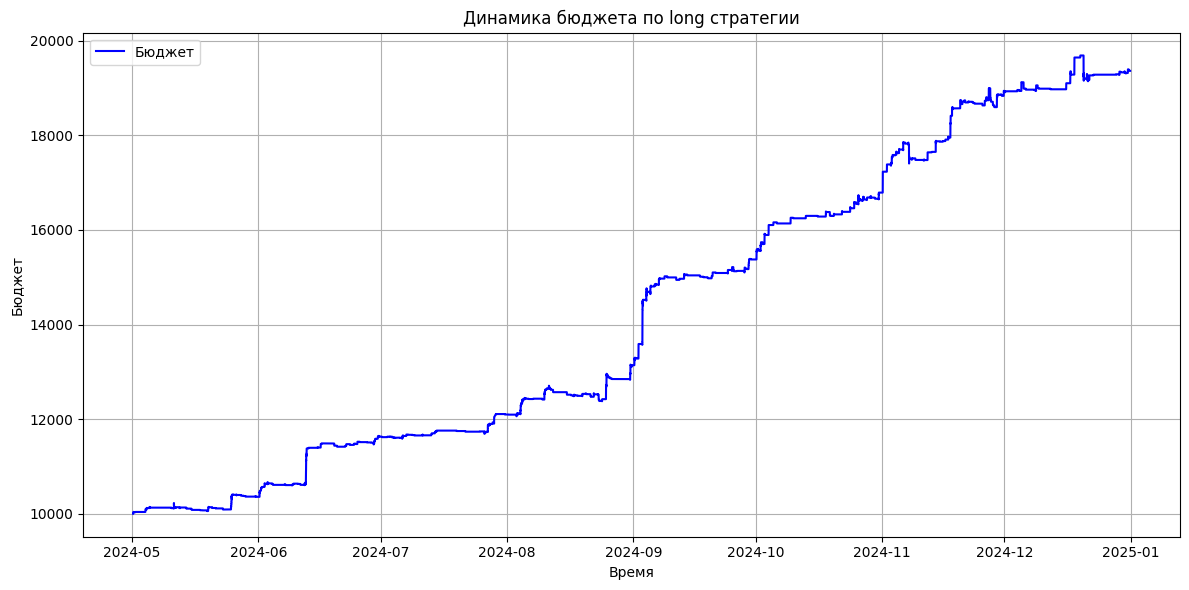

In [10]:
df = pd.read_csv('my_favorite.csv')
df['utc'] = pd.to_datetime(df['utc'])
df = df.sort_values('utc')

threshold = 0.5
df['predicted_class'] = (df['predicted_proba'] > threshold).astype(int)
df['target'] = (df['close'].shift(-1) >= df['close']).astype(int)
df['group_id'] = ((df['utc'] - df['utc'].min()).dt.days // 5)
df['close_t+1'] = df['close'].shift(-1)

initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    if signal == 0:  # Long
        n_shares = int(budget // price_next)
        if n_shares == 0:
            pass
        else:
            buy_cost = n_shares * price_next * (1 + commission_rate)
            sell_revenue = n_shares * price_now * (1 - commission_rate)
            budget += (sell_revenue - buy_cost)
            
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()